# <center>**Wildcat Species Image Classification Project**</center>
# <center>Profesor: prof dr Branimir Todorovic</center>
# <center>Student: Veljko Petkovic 138PH</center>
## Introduction

I built a convolutional neural network (CNN) to classify images of four wildcat species: caracal, cheetah, puma, and tiger. I implemented this model using a custom deep learning framework made by **Vukasin Stanojevic**. The goal of the project was to see if the model could automatically distinguish between these species in photos. I will explain the dataset I used, the neural network architecture, my training approach, and the improvements I made to increase the model's accuracy.

## Dataset
The dataset for this project contained images of the four wildcat species, with roughly equal numbers of photos for each species. Initially, I had about 235 images (**224** x **224px**) for each class, which came to around 1,000 images in total. All the images were resized to 128×128 pixels to have a consistent input size for the network and not break the memory limit during training which happened multiple times when I tried training on 224x224. I split the data into a training set and a test set (**80%** training and **20%** testing) to evaluate the model’s performance on unseen images. All photos are stored in:

<i>data/four cat photos/</i>

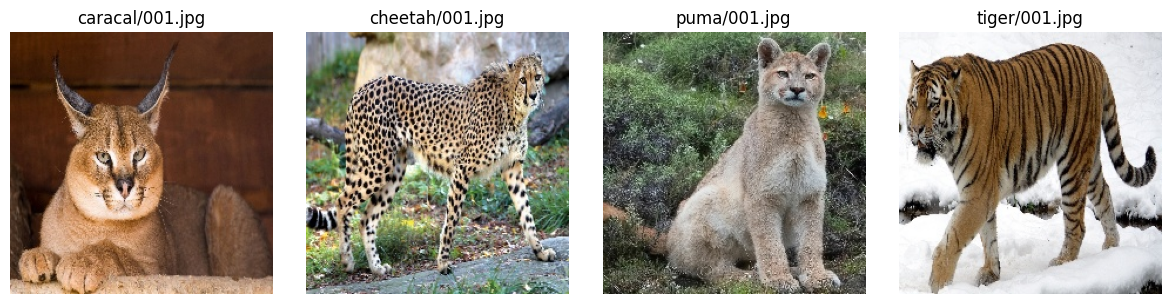

In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

cats = ["caracal", "cheetah", "puma", "tiger"]

plt.figure(figsize=(12, 3))

for i, cat in enumerate(cats):
    img = mpimg.imread("data/four cats photos/" + cat + "/001.jpg")
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.title(cat + "/001.jpg")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Model Architecture
I used a _VGG-like_ CNN architecture (simpler than a full VGG network but still deep enough to learn useful features from the images). This CNN architecture I used has three blocks of convolutional layers (each block followed by a pooling layer), then a couple of fully connected layers. In total, the network has six convolutional layers with increasing numbers of filters, followed by a flatten layer and two dense (fully connected) layers. The final architecture can be summarized as follows:


- **Convolutional Block 1**: Two convolutional layers with **16** filters (`3×3 kernel`, `padding=1`), each followed by a **ReLU** activation, then a `2×2` **max pooling** layer.
- **Convolutional Block 2**: Two convolutional layers with **32** filters (`3×3 kernel`, `padding=1`) + **ReLU** activations, then a `2×2` **max pooling** layer
- **Convolutional Block 3**: Two convolutional layers with **64** filters (`3×3 kernel`, `padding=1`) + **ReLU** activations, then a `2×2` **max pooling** layer
- **Fully Connected Layers**: A flatten layer to turn the feature maps into a vector, then one dense layer with 128 neurons (with **ReLU**), followed by a dropout layer using `p = 0.3` (_**layers/dropout_layer.py**_), and finally a dense output layer with 4 units (one for each wildcat class).
- **Loss**: _CrossEntropy_ (from logits)
- **Optimizer**: _RMSProp_ with `learning rate = 2e-4` (0.0002) and `beta = 0.98`
- **Batch size**: 16
- **Number of epochs**: 12


Code of the model can be found at ***test_examples/four_cat_species.py***

## Training Strategy

I used a standard cross-entropy loss function for training since this is a **multi-class classification** task (four classes). The optimizer was RMSProp with a learning rate of 2×10^−4 (0.0002) and a beta value of 0.98 for the moving average. I trained the network using mini-batches of 16 images (batch size = 16) for 12 epochs. Training the model from scratch with my own framework was slower than using optimized libraries, but 12 epochs was manageable with the dataset size (it took several hours to train).


I applied simple _data augmentation_ to help the model generalize better. In each epoch, I randomly flipped some training images horizontally with a 40% probability. This horizontal flip augmentation effectively increased the variety of training examples without actually collecting more images. I also included a _dropout layer_ (*Dropout(p=0.3)*) (dropping 30% of the neurons in the fully connected layer during each update) to reduce **overfitting**. These techniques (augmentation and dropout) were important given the small size of the dataset, as they forced the model to learn more robust features.


I experimented with various hyperparameters throughout the project to see if they would improve the results. I tried changing the batch size (for example, using 8 or 32 instead of 16), adjusting the learning rate (making it higher or lower), changing the RMSProp beta value, using different image input sizes (like 64×64 or 224x224), and training for more epochs. However, **none** of these hyperparameter changes gave a significant boost in accuracy. The model’s test accuracy remained around the ~60% range after these experiments. It became clear that the limited and sometimes noisy dataset was the main problem, rather than just the choice of hyperparameters.


## Improvements and Final Results

The most important improvement came from **cleaning the dataset**. After reviewing the results and some of the images, I realized that some of the photos were low-quality. These problematic images were likely confusing the network. I went through each class’s images and removed about 35 poor-quality or irrelevant pictures from each class. This reduced each class from 235 images to about 200 higher-quality images. By training the model on this cleaned dataset (with the same architecture and training parameters as before), I noticed a significant improvement in performance.


With the cleaner dataset (and using data augmentation and dropout as described), the model’s test accuracy jumped to around **73.75**%. This was a big increase compared to the ~60% accuracy from the initial model and even the ~65% I achieved after adding augmentation and dropout earlier. Although ~74% accuracy is far from perfect, I was very happy to see this improvement. It demonstrated how crucial data quality is for deep learning projects – removing not so relevant data helped the model learn much better.


In the end, 73.75% was the highest test accuracy I achieved for the wildcat classification task. This experience taught me that improving the dataset can have a larger impact than just tweaking hyperparameters. I also learned the value of techniques like data augmentation and regularization (dropout) to get the most out of a small dataset. Overall, building a CNN from scratch for this project was challenging but rewarding, and it helped me understand both the strengths and limitations of my model.

In [ ]:
"""
Training:	Epoch: 1, loss: 1.6199990549864367.
Metric: Training accuracy value: 0.325
--------------------------------------------------

Training:	Epoch: 2, loss: 1.167497616646283.
Metric: Training accuracy value: 0.5062
--------------------------------------------------

Training:	Epoch: 3, loss: 0.9862018669424707.
Metric: Training accuracy value: 0.5938
--------------------------------------------------

...

Training:	Epoch: 11, loss: 0.31934097807264095.
Metric: Training accuracy value: 0.9125
--------------------------------------------------

Training:	Epoch: 12, loss: 0.26520870917449435.
Metric: Training accuracy value: 0.9219
--------------------------------------------------

Training time = 15598.963396310806 seconds
Parameters saved at saved_models/params_four_cat_species.pickle
Model saved at saved_models/model_four_cat_species_73_accuracy.pickle
Test set loss = 0.7861926929086269
Metric: accuracy, value: 0.7375
"""

Training lasted 15,598 seconds (approximately 4 hours and 19 minutes) on Google Colab using the CPU. Unfortunately, during the final training run, a T4 GPU was not available, unlike in previous training sessions where GPU acceleration was used and training lasted only 20-30 minutes. A cross-entropy loss of 0.78 for a 4-class classification task is consistent with the achieved test accuracy of about 73%. Model is saved at _**saved_models/model_four_cat_species_73_accuracy.pickle**_ and we are going to use it now for additional testing and visualizing results


## Testing and Visualization on Unseen Images

Next, we evaluate the model using a separate test folder _**data/four_cat_species/test/**_ to see how well it predicts new images.

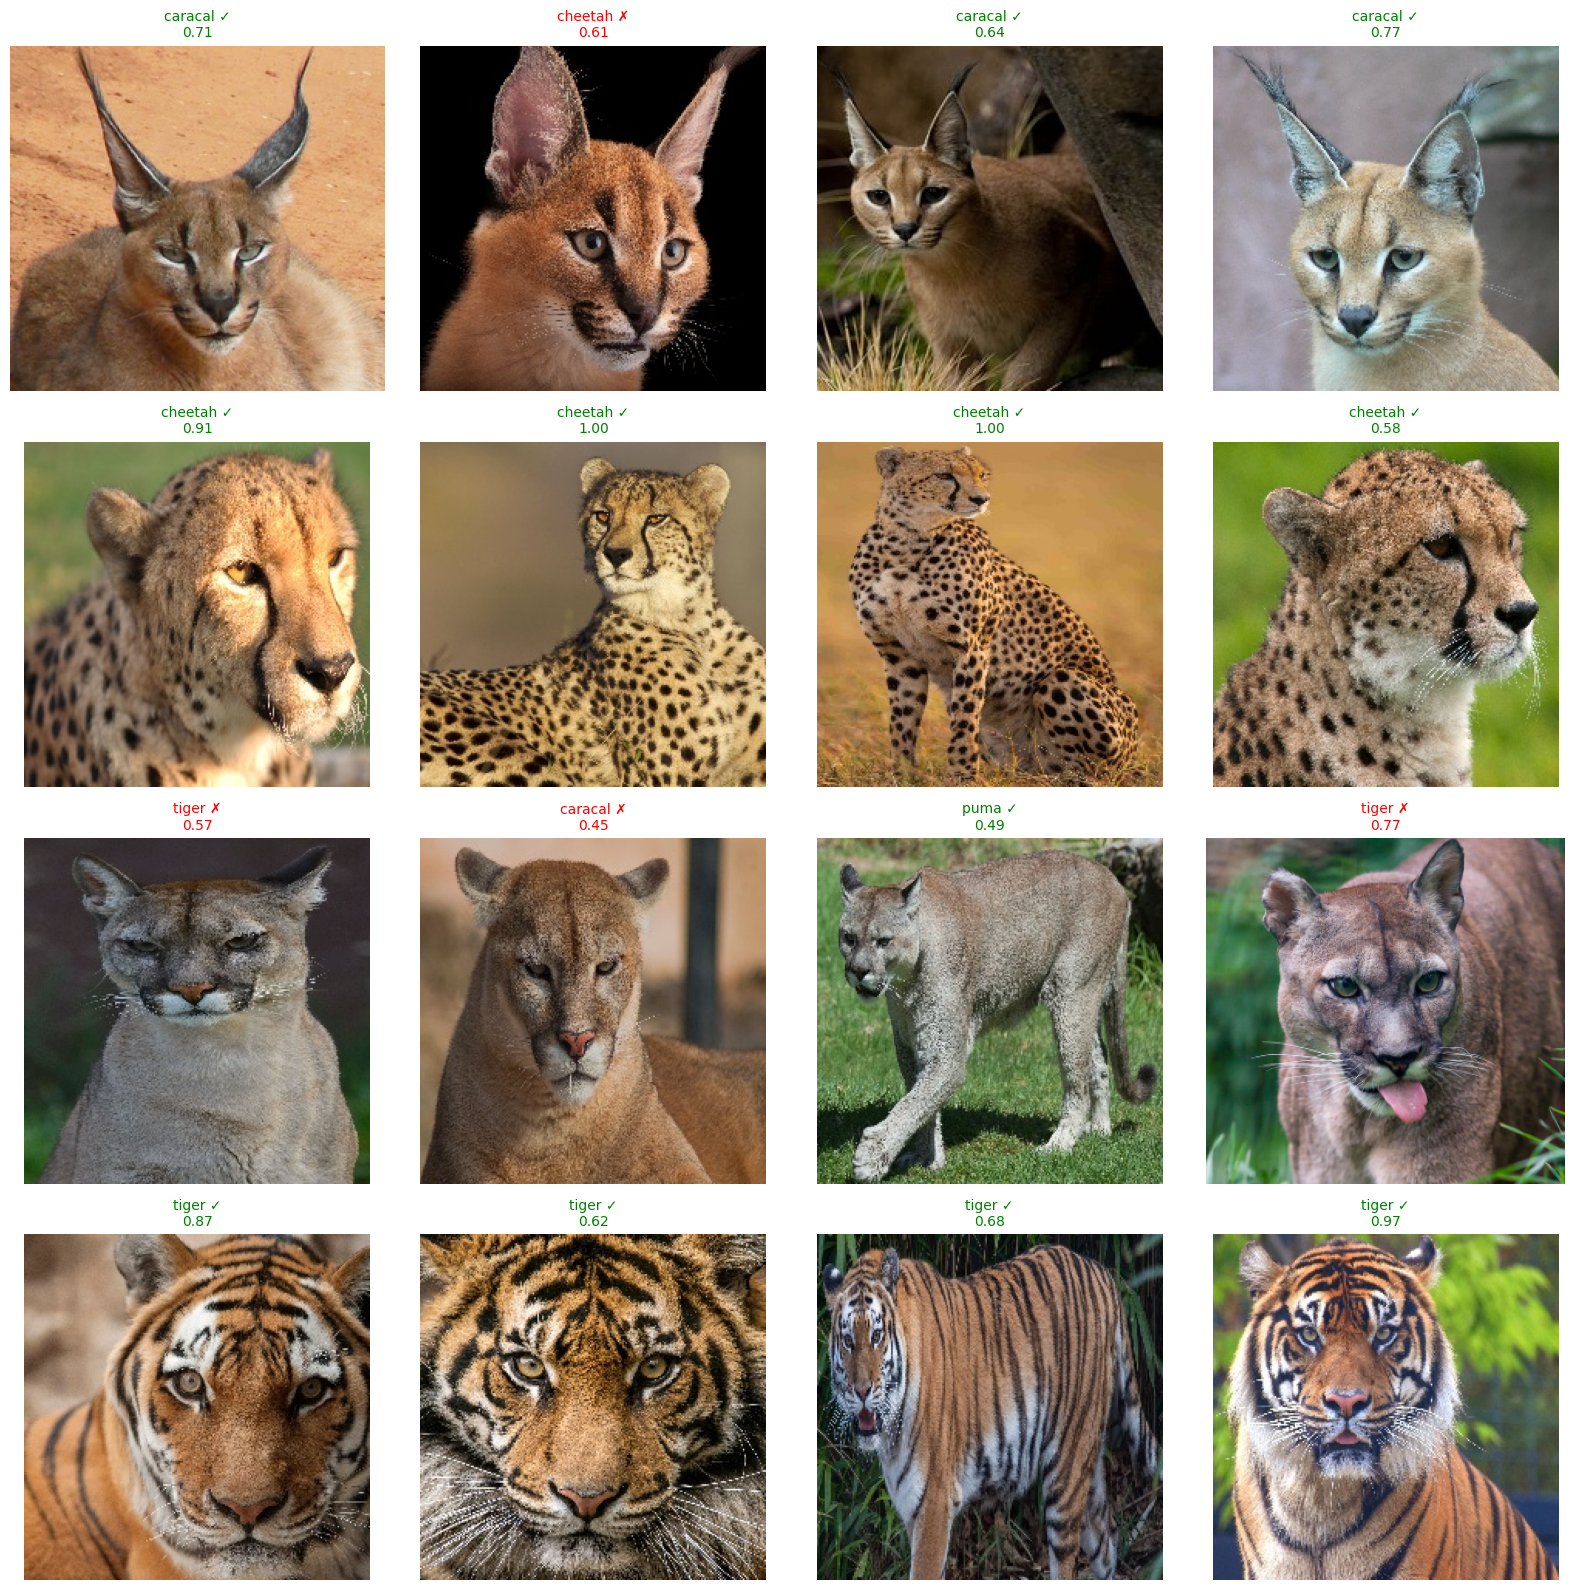

In [22]:
import os
import cv2
import numpy as xp
import matplotlib.pyplot as plt
from models.feedforward_nn import Model

model = Model.load("saved_models/model_four_cat_species_73_accuracy.pickle")
model.training = False

class_names = ["caracal", "cheetah", "puma", "tiger"]

base_dir = "data/four cats photos/test"
folders = ["CARACAL", "CHEETAH", "PUMA", "TIGER"]

def load_single_image(path, img_size=128):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Could not load image: {path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img_size, img_size))

    x = xp.array(img_resized, dtype=xp.float32) / 255.0
    x = x.transpose(2, 0, 1)
    x = x[xp.newaxis, ...]

    return img, x

def predict_single_image(model, x):
    logits = model(x)

    logits = logits - xp.max(logits, axis=1, keepdims=True)
    probs = xp.exp(logits)
    probs = probs / xp.sum(probs, axis=1, keepdims=True)

    probs = probs[0]
    pred_idx = int(xp.argmax(probs))
    confidence = float(probs[pred_idx])

    return pred_idx, confidence

fig, axes = plt.subplots(len(folders), 4, figsize=(16, 4 * len(folders)))

for row, folder in enumerate(folders):
    folder_path = os.path.join(base_dir, folder)

    image_files = sorted(
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )[:4]

    true_label = class_names.index(folder.lower())

    for col, img_name in enumerate(image_files):
        path = os.path.join(folder_path, img_name)
        original_img, x = load_single_image(path)

        pred_idx, confidence = predict_single_image(model, x)
        pred_class = class_names[pred_idx]

        is_correct = (pred_idx == true_label)
        symbol = "✓" if is_correct else "✗"
        title_color = "green" if is_correct else "red"

        ax = axes[row, col]
        ax.imshow(original_img)
        ax.axis("off")

        ax.set_title(f"{pred_class} {symbol}\n{confidence:.2f}", fontsize=10, color=title_color)

    axes[row, 0].set_ylabel(folder, fontsize=12, rotation=0, labelpad=40)

plt.tight_layout()
plt.show()


Based on the predictions shown in previous photo, the model performs best on **tiger** and **cheetah** images, which is likely due to their very distinctive skin textures and patterns (stripes for tigers and spots for cheetahs). These strong visual features are easy for a convolutional neural network to learn and recognize consistently.

The model struggles more with **puma**, as pumas visually look like caracals in body shape and skin color, which leads to frequent confusion between these two classes. However, **caracal** predictions are still relatively good because caracals have large, distinctive ears, a feature that the neural network can detect reliably.

## Per-class accuracy analysis

This type of analysis helps identify which classes the model predicts well and which classes are more challenging, providing deeper insight into class imbalance, visual similarity, and model behavior.

In [24]:
import pickle
from test_examples.four_cat_species import get_images

with open("saved_models/model_four_cat_species_73_accuracy.pickle", "rb") as f:
    model = pickle.load(f)

X, y = get_images(img_size=128, max_photos=200)
X = X.transpose(0, 3, 1, 2)

idx = xp.random.permutation(len(X))
X, y = X[idx], y[idx]

y_true = y
y_pred = []

for i in range(len(X)):
    logits = model(X[i:i+1])
    pred = xp.argmax(logits, axis=1)[0]
    y_pred.append(pred)

y_pred = xp.array(y_pred)

class_names = ["caracal", "cheetah", "puma", "tiger"]

for class_id, class_name in enumerate(class_names):
    mask = (y_true == class_id)
    correct = xp.sum(y_pred[mask] == y_true[mask])
    total = xp.sum(mask)

    acc = correct / total if total > 0 else 0
    print(f"{class_name}: {acc:.2f}")

caracal: 0.82
cheetah: 0.94
puma: 0.72
tiger: 0.84


Per-class accuracy results show that the model performs **best** on cheetah images (94%), followed by tiger (84%) and caracal (82%). The **lowest** performance is observed for the puma class (72%), which is expected due to its visual similarity to caracal images.

## Confusion matrix

A confusion matrix is a table that compares the true class labels with the model’s predicted labels for each class. It helps visualize correct predictions and identify where the model most often makes mistakes between different classes.

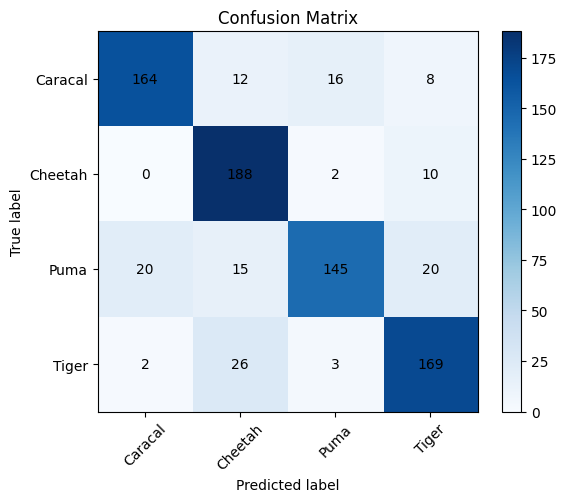

In [27]:
import matplotlib.pyplot as plt
import numpy as np

num_classes = 4
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

for t, p in zip(y_true, y_pred):
    conf_matrix[t, p] += 1

class_names = ["Caracal", "Cheetah", "Puma", "Tiger"]

plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap="Blues")
plt.colorbar()

plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()


The confusion matrix confirms that the model performs very well on cheetah and tiger classes, with most predictions correctly placed on the diagonal. The largest source of error is between puma and caracal, where puma images are often misclassified as caracal and vice versa, which aligns with their similar appearance, while caracal accuracy remains relatively high due to its distinctive ear shape.


## Limitations
The main limitation of this project is the relatively small dataset size, which restricts the model’s ability to generalize to a wider variety of images. Visual similarity between certain classes, especially puma and caracal, leads to frequent misclassifications and limits overall performance. In addition, the model was trained from scratch without transfer learning, which reduces performance compared to approaches that use large pre-trained networks implemented in frameworks like PyTorch.

## Future Work
Future work could focus on collecting more images to improve the model’s ability to generalize. Using pre-trained models instead of training from scratch may lead to better performance. Additional image variations, such as changes in color or lighting, could also help the model become better.

## Conclusion
In this project, a convolutional neural network was built from scratch to classify images of four wildcat species: caracal, cheetah, puma, and tiger. The model achieved a test accuracy of approximately 73%, with strong performance on cheetah and tiger images and more difficulty distinguishing between visually similar classes such as puma and caracal. Overall, the results show that careful dataset cleaning and analysis can significantly improve model performance, even when working with a limited amount of data.